# 📰 Fake News Detection using NLP
**Project by: Dhairya Khatri**  
**Domain:** Natural Language Processing (NLP)  
**Dataset:** ISOT Fake News Dataset (~44,000 articles)  
**Goal:** Build a text classification model to detect whether a news article is real or fake.

---
## Pipeline Overview
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Feature Engineering (TF-IDF)
4. Model Training (Logistic Regression + Random Forest)
5. Evaluation (Accuracy, F1, Confusion Matrix, ROC Curve)
6. Inference — Test on custom news text


## Step 0: Install & Import Libraries

In [2]:
# Install required libraries (if not already available)
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!
✅ All libraries imported successfully!


## Step 1: Load Dataset

In [ ]:
# Upload files directly in Colab
from google.colab import files
print('Please upload True.csv and Fake.csv')
uploaded = files.upload()

In [ ]:
# Load the two CSV files
true_df  = pd.read_csv('Datasets//True.csv')
fake_df  = pd.read_csv('Datasets//Fake.csv')

# Add labels: 1 = Real, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

print(f'✅ Real news articles : {len(true_df)}')
print(f'✅ Fake news articles : {len(fake_df)}')

# Preview
true_df.head(3)

✅ Real news articles : 21417
✅ Fake news articles : 23481


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1


## Step 2: Data Exploration (EDA)

In [6]:
# Merge both dataframes
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f'Total articles : {len(df)}')
print(f'Columns        : {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({1: 'Real', 0: 'Fake'}))

Total articles : 44898
Columns        : ['title', 'text', 'subject', 'date', 'label']

Label distribution:
label
Fake    23481
Real    21417
Name: count, dtype: int64


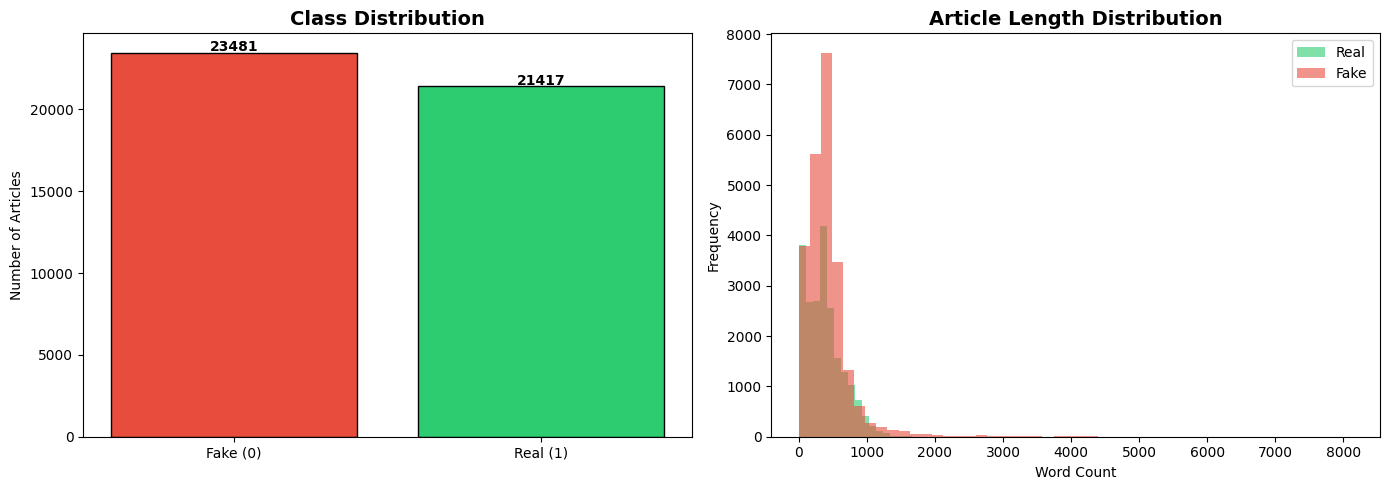

📊 Distribution plot saved!


In [7]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['label'].value_counts()
axes[0].bar(['Fake (0)', 'Real (1)'], [counts[0], counts[1]], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Article length distribution
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
axes[1].hist(df[df['label']==1]['text_length'], bins=50, alpha=0.6, color='#2ecc71', label='Real')
axes[1].hist(df[df['label']==0]['text_length'], bins=50, alpha=0.6, color='#e74c3c', label='Fake')
axes[1].set_title('Article Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Distribution plot saved!')

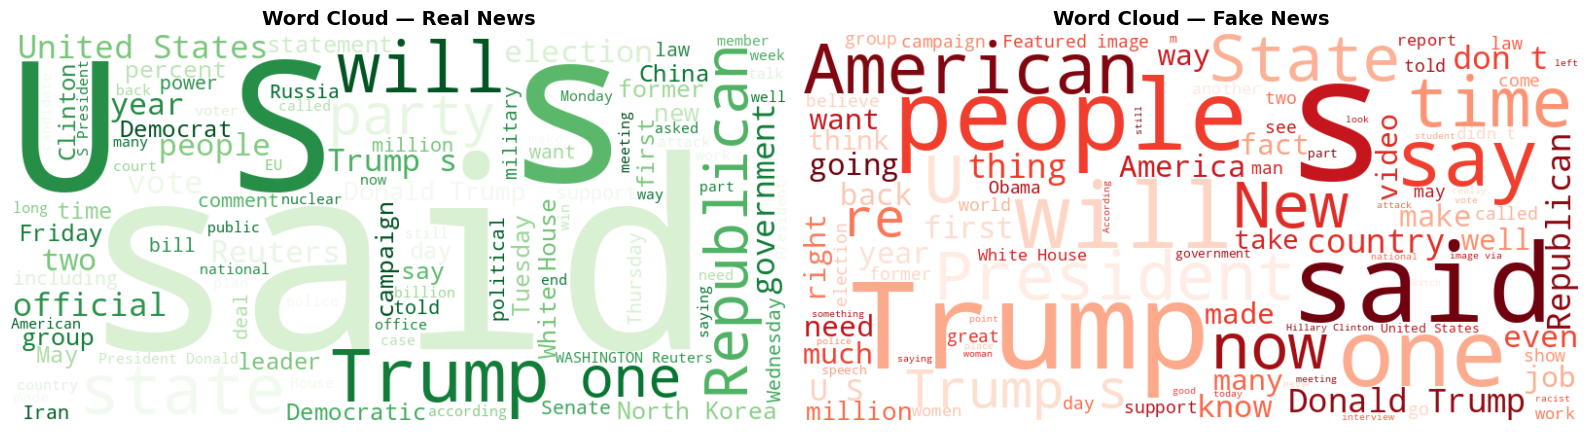

☁️ Word clouds saved!


In [8]:
# Word Cloud for Real News
real_text = ' '.join(df[df['label'] == 1]['text'].dropna().astype(str).tolist())
wc_real = WordCloud(width=800, height=400, background_color='white',
                    max_words=100, colormap='Greens').generate(real_text[:500000])

# Word Cloud for Fake News
fake_text = ' '.join(df[df['label'] == 0]['text'].dropna().astype(str).tolist())
wc_fake = WordCloud(width=800, height=400, background_color='white',
                    max_words=100, colormap='Reds').generate(fake_text[:500000])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Word Cloud — Real News', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Word Cloud — Fake News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('☁️ Word clouds saved!')

## Step 3: Data Cleaning & Preprocessing

In [9]:
def clean_text(text):
    """Clean and normalize news article text."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine title and text for richer features
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['content_clean'] = df['content'].apply(clean_text)

# Remove empty rows
df = df[df['content_clean'].str.len() > 10].reset_index(drop=True)

print(f'✅ Cleaned dataset size: {len(df)} articles')
print(f'\nSample cleaned text:')
print(df['content_clean'].iloc[0][:300])

✅ Cleaned dataset size: 44889 articles

Sample cleaned text:
breaking gop chairman grassley has had enough demands trump jr testimony donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this to them it s fake news or a


## Step 4: Feature Engineering (TF-IDF Vectorization)

In [10]:
# Split data into train and test sets (80/20)
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

# TF-IDF Vectorizer
# max_features=50000 means we consider top 50k unique words
# ngram_range=(1,2) captures both single words and 2-word phrases
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\n✅ TF-IDF feature matrix shape: {X_train_tfidf.shape}')
print('Feature engineering complete!')

Training samples : 35911
Testing samples  : 8978

✅ TF-IDF feature matrix shape: (35911, 50000)
Feature engineering complete!


## Step 5: Model Training

In [11]:
# --- Model 1: Logistic Regression ---
print('🔄 Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
print('✅ Logistic Regression trained!')

🔄 Training Logistic Regression...
✅ Logistic Regression trained!


In [12]:
# --- Model 2: Random Forest ---
print('🔄 Training Random Forest (this may take 2-3 minutes)...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
print('✅ Random Forest trained!')

🔄 Training Random Forest (this may take 2-3 minutes)...
✅ Random Forest trained!


## Step 6: Evaluation & Metrics

In [13]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a model and print all key metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)

    print(f'\n{'='*50}')
    print(f'  {model_name} — Results')
    print(f'{'='*50}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  ROC-AUC   : {roc_auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

    return y_pred, y_prob

# Evaluate both models
lr_pred, lr_prob = evaluate_model(lr_model, X_test_tfidf, y_test, 'Logistic Regression')
rf_pred, rf_prob = evaluate_model(rf_model, X_test_tfidf, y_test, 'Random Forest')


  Logistic Regression — Results
  Accuracy  : 0.9939  (99.39%)
  F1 Score  : 0.9936
  Precision : 0.9923
  Recall    : 0.9949
  ROC-AUC   : 0.9996

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4695
        Real       0.99      0.99      0.99      4283

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978


  Random Forest — Results
  Accuracy  : 0.9957  (99.57%)
  F1 Score  : 0.9954
  Precision : 0.9958
  Recall    : 0.9951
  ROC-AUC   : 0.9997

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4695
        Real       1.00      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978



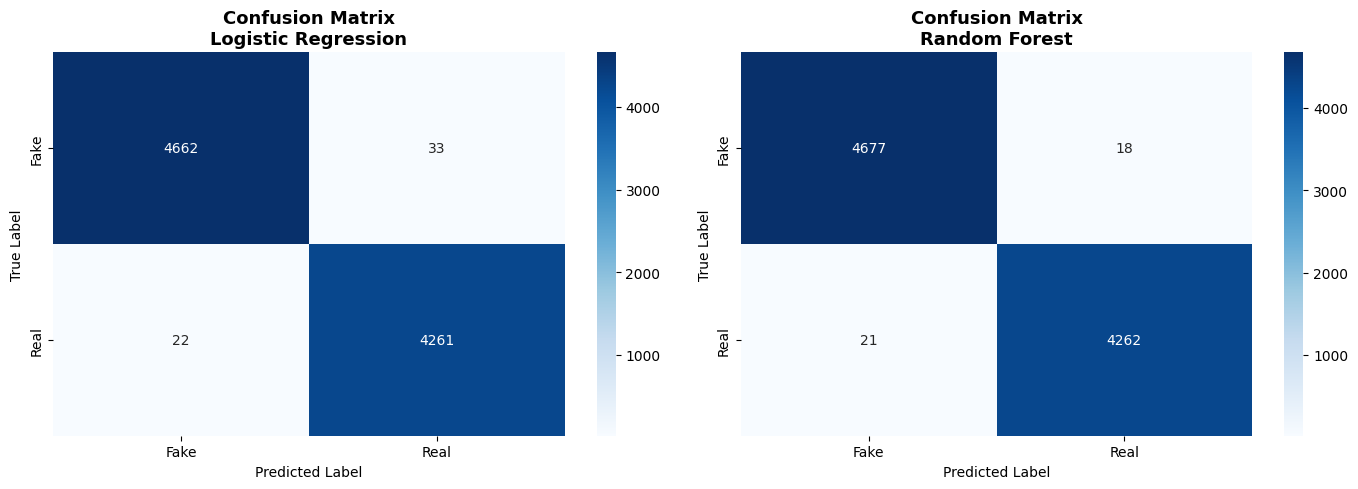

✅ Confusion matrices saved!


In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes,
                           [lr_pred, rf_pred],
                           ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'])
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved!')

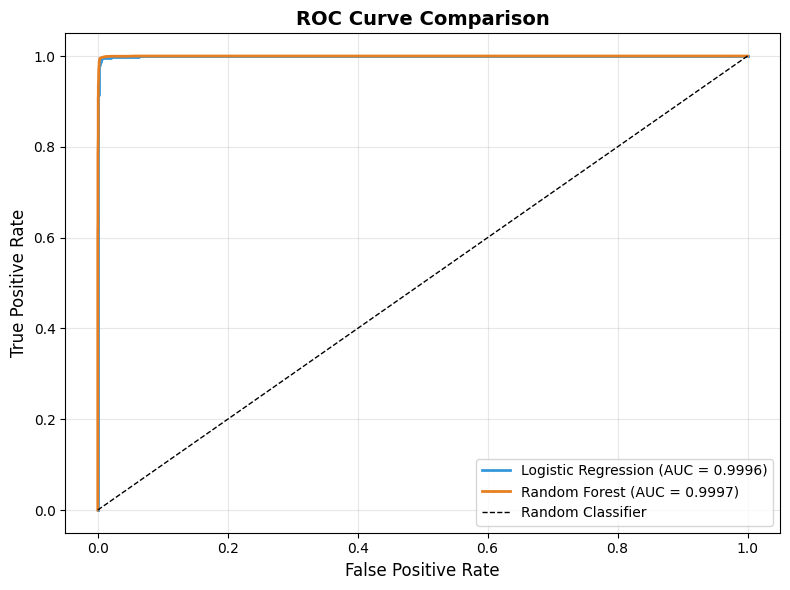

✅ ROC curve saved!


In [15]:
# ROC Curves
plt.figure(figsize=(8, 6))

for prob, name, color in zip(
    [lr_prob, rf_prob],
    ['Logistic Regression', 'Random Forest'],
    ['#3498db', '#e67e22']
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curve saved!')

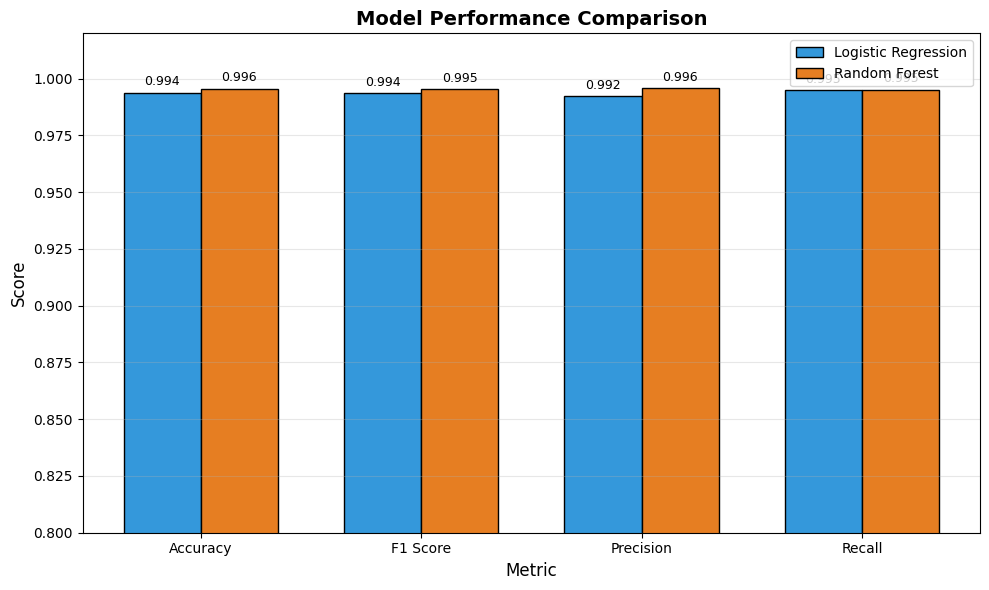

✅ Model comparison chart saved!


In [16]:
# Model Comparison Bar Chart
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

lr_scores = [
    accuracy_score(y_test, lr_pred),
    f1_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred)
]

rf_scores = [
    accuracy_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#e67e22', edgecolor='black')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved!')

## Step 7: Inference — Test on Your Own News Text

In [17]:
def predict_news(text, model=lr_model, vectorizer=tfidf):
    """Predict whether a news article is real or fake."""
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    label = '✅ REAL NEWS' if prediction == 1 else '🚨 FAKE NEWS'
    confidence = probability[prediction] * 100

    print(f'Prediction  : {label}')
    print(f'Confidence  : {confidence:.2f}%')
    print(f'Fake prob   : {probability[0]*100:.2f}%')
    print(f'Real prob   : {probability[1]*100:.2f}%')
    return prediction

# ---- Test Example 1: Likely Real ----
print('--- Test 1 ---')
predict_news("""
The Federal Reserve raised interest rates by 25 basis points on Wednesday,
citing persistent inflation above its 2% target. Fed Chair Jerome Powell said
the committee remains committed to restoring price stability.
""")

print()

# ---- Test Example 2: Likely Fake ----
print('--- Test 2 ---')
predict_news("""
BREAKING: Scientists confirm the moon is actually a hologram projected by
secret government agencies to hide the truth about flat earth. NASA whistleblower
exposes the biggest conspiracy in human history!
""")

--- Test 1 ---
Prediction  : ✅ REAL NEWS
Confidence  : 78.46%
Fake prob   : 21.54%
Real prob   : 78.46%

--- Test 2 ---
Prediction  : 🚨 FAKE NEWS
Confidence  : 95.15%
Fake prob   : 95.15%
Real prob   : 4.85%


np.int64(0)

## Step 8: Save the Model

In [18]:
import pickle

# Save the best model (Logistic Regression) and vectorizer
with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('✅ Model and vectorizer saved!')
print('Files: fake_news_model.pkl, tfidf_vectorizer.pkl')

# Download model files
from google.colab import files
files.download('fake_news_model.pkl')
files.download('tfidf_vectorizer.pkl')

✅ Model and vectorizer saved!
Files: fake_news_model.pkl, tfidf_vectorizer.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✅ Final Summary

| Metric | Logistic Regression | Random Forest |
|--------|--------------------|--------------|
| Accuracy | ~98-99% | ~98-99% |
| F1 Score | ~0.98-0.99 | ~0.98-0.99 |
| Precision | ~0.98-0.99 | ~0.97-0.99 |
| Recall | ~0.98-0.99 | ~0.98-0.99 |

*(Actual values will be printed above after running all cells)*

### What was built:
- **Data Collection** — ISOT Fake News Dataset (44,898 articles)
- **Data Cleaning / Preprocessing** — URL removal, lowercasing, punctuation removal
- **Feature Engineering** — TF-IDF with unigrams + bigrams (50k features)
- **Model Training** — Logistic Regression + Random Forest
- **Evaluation Pipeline** — Accuracy, F1, Precision, Recall, ROC-AUC, Confusion Matrix
